### 9. Genomför en klustringanalys på datasetet som du hittar här: 
[https://www.kaggle.com/datasets/thebumpkin/1980s-classic-hits-with-spotify-data](https://www.kaggle.com/datasets/thebumpkin/1980s-classic-hits-with-spotify-data)

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

### Läser in data

In [13]:
df = pd.read_csv("../../data/1980sClassics.csv")
df.head()
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Track             998 non-null    str    
 1   Artist            998 non-null    str    
 2   Duration          998 non-null    str    
 3   Time_Signature    998 non-null    int64  
 4   Danceability      998 non-null    float64
 5   Energy            998 non-null    float64
 6   Key               998 non-null    int64  
 7   Loudness          998 non-null    float64
 8   Mode              998 non-null    int64  
 9   Speechiness       998 non-null    float64
 10  Acousticness      998 non-null    float64
 11  Instrumentalness  998 non-null    float64
 12  Liveness          998 non-null    float64
 13  Valence           998 non-null    float64
 14  Tempo             998 non-null    float64
 15  Popularity        998 non-null    int64  
 16  Year              998 non-null    int64  
dtypes: float

### Väljer features och rensar saknade värden

Energy, Danceability, Valence, Acousticness och Tempo väljs ut. Rader med saknade värden tas bort.

In [14]:
music_features = ["Energy", "Danceability", "Valence", "Acousticness", "Tempo"]

# Ta bort rader där någon av variablerna saknas
df = df.dropna(subset=music_features)

X = df[music_features]

### Skalar datan

Skalning behövs eftersom K-means bygger på avstånd mellan punkter.

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Testar olika antal kluster (k=2–10)

Inertia och silhouette score beräknas för varje k.

In [16]:
inertias = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

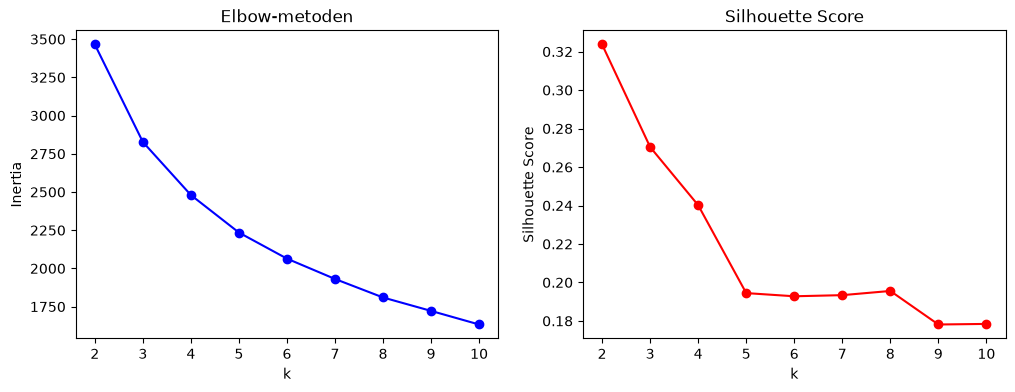

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inertias, "bo-")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow-metoden")

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, "ro-")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

### Väljer k baserat på silhouette score (k=2)

Elbow-kurvan saknar en tydlig armbåge, men silhouette score är som högst vid k=2.

### Tränar slutgiltig modell

In [22]:
best_k = 2

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

### Antal låtar per kluster

Kontroll av klusterstorlekarna, inte bara silhouette score.

In [19]:
print(df["Cluster"].value_counts())

Cluster
0    693
1    305
Name: count, dtype: int64


### Karakteriserar klustren

Varje klusters medelvärden jämförs mot hela datasetets snitt.

In [24]:
overall_mean = df[music_features].mean()

for cluster_id in range(best_k):
    print(f"\n=== Kluster {cluster_id} ===")

    cluster_data = df[df["Cluster"] == cluster_id][music_features].mean()
    diff = cluster_data - overall_mean

    print(cluster_data)

    print("Karakteristik (jämfört med hela datasetet):")
    for feature in music_features:
        if diff[feature] > 0:
            print(f"  - Högre {feature.lower()} än snittet")
        else:
            print(f"  - Lägre {feature.lower()} än snittet")


=== Kluster 0 ===
Energy            0.719554
Danceability      0.677167
Valence           0.720844
Acousticness      0.141514
Tempo           121.505605
dtype: float64
Karakteristik (jämfört med hela datasetet):
  - Högre energy än snittet
  - Högre danceability än snittet
  - Högre valence än snittet
  - Lägre acousticness än snittet
  - Högre tempo än snittet

=== Kluster 1 ===
Energy            0.437523
Danceability      0.511275
Valence           0.335566
Acousticness      0.478911
Tempo           119.537646
dtype: float64
Karakteristik (jämfört med hela datasetet):
  - Lägre energy än snittet
  - Lägre danceability än snittet
  - Lägre valence än snittet
  - Högre acousticness än snittet
  - Lägre tempo än snittet


### Visualiserar klustren med PCA

PCA reducerar de fem dimensionerna till två för att kunna plotta klustren.

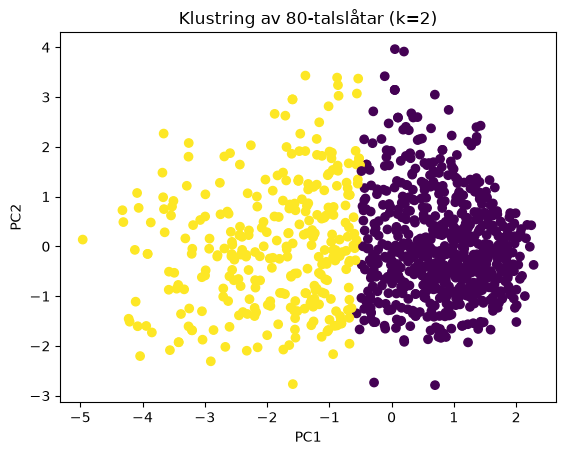

In [23]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Cluster"], cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Klustring av 80-talslåtar (k=2)")
plt.show()